In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans


In [5]:
image_path =  r'C:\Korner flag\output_videos\player_1.jpg' 
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

<function matplotlib.pyplot.show(close=None, block=None)>

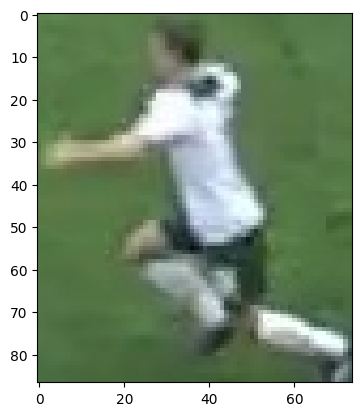

In [7]:
plt.imshow(image)
plt.show

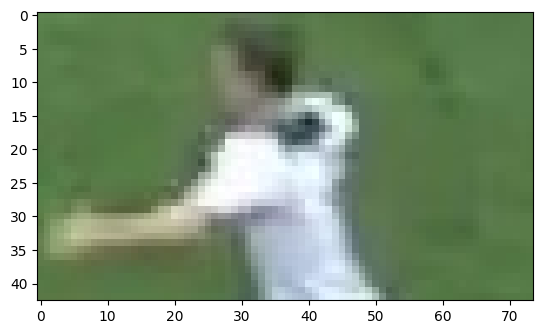

In [8]:
#Take off the background of the image and assign a color to the player

top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

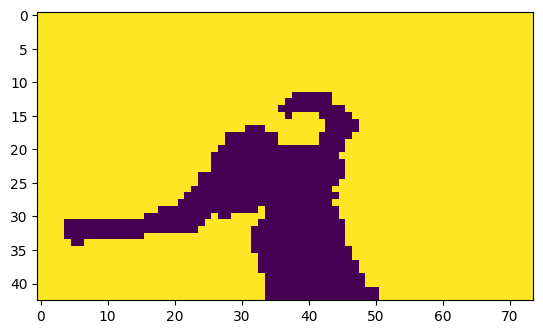

In [12]:
# Cluster the image into 2 clusters using KMeans

image_2d = top_half_image.reshape(-1, 3)

kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

#get the cluster lables
labels = kmeans.labels_

# resahape the labels back to the original image shape

clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

#Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [13]:
corner_cluster = [clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1]]
non_player_cluster = max(set(corner_cluster), key=corner_cluster.count)
print(non_player_cluster)

1


In [14]:
player_cluster = 1- non_player_cluster
print(player_cluster)

0


In [15]:
kmeans.cluster_centers_[player_cluster]

array([198.87150838, 208.97579143, 211.67597765])